#Bài tập trên lớp

## Bài tập 1:

In [1]:
# Bài toán tìm kiếm nhị phân
def binary_search(a,x,l,r):
  if l == r:
    if x == a[l]:
      return 1
    else:
      return -1
  else:
    m = int((l+r)/2)
    if x == a[m]:
      return m
    elif x < a[m]:
      return binary_search(a,x,l,m-1)
    else:
      return binary_search(a,x,m+1, r)

a=[1,3,32,3,4,6,43,78,3,23,4]

print(binary_search(a,3,0,len(a)-1))

1


### 3. Sử dụng thuật toán QuickSort để sắp xếp các giá trị trong một mảng các số theo một thứ tự nào đó (có thể tăng dần hoặc giảm dần).

In [2]:
def quick_sort(a, l, r):
  if l < r:
    i = l
    j = r
    x = a[int((l+r)/2)]
    while i <= j:
      while a[i] < x:
        i += 1
      while a[j] > x:
        j -= 1
      if i <= j:
        a[i], a[j] = a[j], a[i]
        i += 1
        j -= 1
    quick_sort(a, l, j)
    quick_sort(a, i, r)

a = [1, 3, 32, 3, 4, 6, 43, 78, 3, 23, 4]
quick_sort(a, 0, len(a) - 1)
print(a)

[1, 3, 3, 3, 4, 4, 6, 23, 32, 43, 78]


 ### 1. Cho một mảng số nguyên. Tìm phần tử có giá trị lớn nhất và nhỏ nhất.

In [3]:
# Bài toán Min,Max
def min(a,l,r):
  if l==r:
    return a[l]
  else:
    min1=min(a,l,(l+r)//2)
    min2=min(a,(l+r)//2+1, r)
    if min1<min2:
      return min1
    else:
      return min2

def max(a,l,r):
  if l==r:
    return a[l]
  else:
    max1=max(a,l,(l+r)//2)
    max2=max(a,(l+r)//2+1, r)
    if max1>max2:
      return max1
    else:
      return max2


a=[1,3,32,3,4,6,43,78,3,23,4]
print(min(a,0,len(a)-1))
print(max(a,0,len(a)-1))

1
78


### 2. Cho hai ma trận vuông A, B cấp n trong đó n là lũy thừa của 2. Tìm tích của hai ma trận trên theo phương pháp chia để trị thông thường và áp dụng thuật toán Strassen.

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Bài toán nhân 2 ma trận n x n
def multiply_matrix(a,b):
  m=len(a)
  n=len(b)
  p=len(b[0])
  c=[[0 for i in range(p)] for j in range(m)]
  for i in range(m):
    for j in range(p):
      for k in range(n):
        c[i][j]+=a[i][k]*b[k][j]
  return c

In [6]:
# Bài toán nhân 2 ma trận n x n sử dụng công thức Strassen
import numpy as np
def multiply_matrix_strassen(a,b,n):
  if n == 1:
    return a*b
  half_n = n // 2

# Split matrices into sub-matrices
  a11 = a[:half_n, :half_n]
  a12 = a[:half_n, half_n:]
  a21 = a[half_n:, :half_n]
  a22 = a[half_n:, half_n:]

  b11 = b[:half_n, :half_n]
  b12 = b[:half_n, half_n:]
  b21 = b[half_n:, :half_n]
  b22 = b[half_n:, half_n:]

  # Recursive calls (**Corrected**)
  p1 = multiply_matrix_strassen(a11 + a22, b11 + b22, half_n)
  p2 = multiply_matrix_strassen(a21 + a22, b11, half_n)
  p3 = multiply_matrix_strassen(a11, b12 - b22, half_n)
  p4 = multiply_matrix_strassen(a22, b21 - b11, half_n)
  p5 = multiply_matrix_strassen(a11 + a12, b22, half_n)
  p6 = multiply_matrix_strassen(a21 - a11, b11 + b12, half_n)
  p7 = multiply_matrix_strassen(a12 - a22, b21 + b22, half_n)

  c11 = p1 + p4 - p5 + p7
  c12 = p3 + p5
  c21 = p2 + p4
  c22 = p1 - p2 + p3 + p6

  c = np.zeros((n, n))
  c[:n//2, :n//2] = c11
  c[:n//2, n//2:] = c12
  c[n//2:, :n//2] = c21
  c[n//2:, n//2:] = c22

  return c


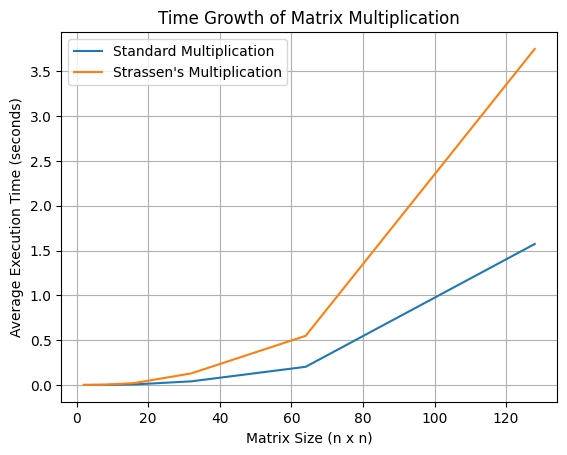

In [7]:
# Generate random matrices of different sizes
sizes = [2**i for i in range(1, 8)]  # Matrix sizes from 2x2 to 128x128
num_runs = 20  # Number of times to run the experiment

# Open a file to store the results
with open("matrix_multiplication_results.txt", "w") as file:
    file.write("Size,Standard_Time,Strassen_Time\n")  # Header row

    for size in sizes:
        for _ in range(num_runs):
            # Create random matrices
            a = np.random.rand(size, size)
            b = np.random.rand(size, size)

            # Measure time for standard multiplication
            start_time = time.time()
            multiply_matrix(a, b)
            end_time = time.time()
            standard_time = end_time - start_time

            # Measure time for Strassen's multiplication
            start_time = time.time()
            multiply_matrix_strassen(a, b, size)
            end_time = time.time()
            strassen_time = end_time - start_time

            # Write the results to the file
            file.write(f"{size},{standard_time},{strassen_time}\n")

# Analyze the data and plot the results
import pandas as pd

# Read the data from the file
data = pd.read_csv("matrix_multiplication_results.txt")

# Group the data by size and calculate the average execution time
average_times = data.groupby("Size")[["Standard_Time", "Strassen_Time"]].mean()

# Plot the results
plt.plot(average_times.index, average_times["Standard_Time"], label="Standard Multiplication")
plt.plot(average_times.index, average_times["Strassen_Time"], label="Strassen's Multiplication")
plt.xlabel("Matrix Size (n x n)")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Time Growth of Matrix Multiplication")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from bisect import bisect_left, bisect_right

def majorityElement(nums):
    n = len(nums)
    mid_element = nums[n // 2]  # Candidate for majority element

    # Find first and last occurrence using binary search
    first = bisect_left(nums, mid_element)
    last = bisect_right(nums, mid_element) - 1

    count = last - first + 1  # Number of occurrences

    return mid_element if count > n // 2 else -1  # Return majority element or -1 if not found

# Example usage
nums = [1, 1, 1, 2, 2, 2, 2, 2]  # Sorted array
result = majorityElement(nums)
print(f"Majority Element: {result}" if result != -1 else "No Majority Element")


Majority Element: 2


### 6. Median of two sorted arrays of different sizes.

In [10]:
import sys
import builtins
max = builtins.max

def median_of_two_sorted_arrays(arr1, arr2):
    if len(arr1) > len(arr2):
        arr1, arr2 = arr2, arr1  # Ensuring arr1 is the smaller array

    x, y = len(arr1), len(arr2)
    low, high = 0, x

    while low <= high:
        partitionX = (low + high) // 2
        partitionY = (x + y + 1) // 2 - partitionX

        maxLeftX = -sys.maxsize if partitionX == 0 else arr1[partitionX - 1]
        minRightX = sys.maxsize if partitionX == x else arr1[partitionX]

        maxLeftY = -sys.maxsize if partitionY == 0 else arr2[partitionY - 1]
        minRightY = sys.maxsize if partitionY == y else arr2[partitionY]

        if maxLeftX <= minRightY and maxLeftY <= minRightX:
            if (x + y) % 2 == 0:
                return (max(maxLeftX, maxLeftY) + min(minRightX, minRightY)) / 2
            else:
                return max(maxLeftX, maxLeftY)
        elif maxLeftX > minRightY:
            high = partitionX - 1
        else:
            low = partitionX + 1

# Example usage:
arr1 = [1, 3, 8]
arr2 = [7, 9, 10, 11]
print("Median:", median_of_two_sorted_arrays(arr1, arr2))


Median: 8


## Bài tập 2:


### 1. Bài toán tìm cặp điểm gần nhất (Closest pair of point) (Anany’s book, sec 5.5)

  #### **1. Phân tích bài toán**
  Bài toán Tìm cặp điểm gần nhất yêu cầu tìm hai điểm trong tập `n` điểm trên mặt phẳng 2D sao cho khoảng cách giữa chúng là nhỏ nhất, với khoảng cách được tính bằng công thức Euclidean:
  $$
  d(p_i, p_j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}
  $$

  trong đó:
  $$ p_i = (x_i, y_i) \text{ và } p_j = (x_j, y_j) $$ là các điểm có tọa độ Descartes.
  

#### **2. Thiết kế thuật toán**
1. **Tiền xử lý**: Sắp xếp các điểm theo tọa độ x (mảng $P_x$) và tọa độ y (mảng $P_y$). Việc này mất $O(n logn)$ và chỉ thực hiện một lần.
2. **Chia**:
   - Chia tập điểm thành hai nửa dựa trên tọa độ x trung vị.
   - Gọi \( L \) là tập điểm bên trái và \( R \) là tập điểm bên phải.
3. **Trị**:
   - Đệ quy tìm cặp điểm gần nhất trong \( L \) (khoảng cách $d_L$) và trong \( R \) (khoảng cách $d_R$).
   - Gán $d = \min(d_L, d_R)$.
4. **Kết hợp**:
   - Cặp điểm gần nhất có thể nằm cắt qua đường phân chia. Xem xét một dải có chiều rộng \( 2d \) quanh tọa độ x trung vị (tức là các điểm có tọa độ x trong khoảng $[x_{\text{mid}} - d, x_{\text{mid}} + d]$).
   - Lấy các điểm trong dải này và sắp xếp chúng theo tọa độ y (hoặc sử dụng $P_y$ đã được sắp xếp trước).
   - Với mỗi điểm trong dải, tính khoảng cách với tối đa 7 điểm tiếp theo (do tính chất hình học trong không gian 2D đảm bảo không quá 7 điểm có thể nằm trong khoảng cách $d$ trong một hộp $d \times d$).
5. **Trường hợp cơ sở**:
   - Nếu $n \leq 3$, tính khoảng cách nhỏ nhất trực tiếp bằng cách kiểm tra tất cả các cặp (vẫn tương thích với giảm để trị như trường hợp cơ sở).


### **3. Phân tích thuật toán**

#### **Độ phức tạp thời gian**
- **Tiền xử lý**:
  - Sắp xếp $P_x$ và $P_y$: $O(nlog n)$.
- **Các bước đệ quy**:
  - **Chia**: Chia $L_x$ và $R_x$ là $O(1)$ vì $P_x$ đã được sắp xếp. Chia $P_y$ thành $L_y$ và $R_y$ mất $O(n)$ (quét tuyến tính).
  - **Trị**: Hai lần gọi đệ quy, mỗi lần với $n/2$ điểm.
  - **Kết hợp**:
    - Xây dựng dải: $O(n)$ (quét tuyến tính $P_y$).
    - Sắp xếp dải theo y không cần thiết vì đã dùng $P_y$ đã sắp xếp.
    - Kiểm tra dải: Với mỗi điểm trong dải, kiểm tra tối đa 7 điểm tiếp theo (do tính chất hình học trong 2D đảm bảo không quá 7 điểm nằm trong hộp $d \times d$ trong khoảng cách $d$). Nếu dải có $m$ điểm, bước này là $O(m)$, và vì $m \leq n$, tổng cộng là $O(n)$.
- **Quan hệ đệ quy**:
  - Độ phức tạp thời gian $T(n)$ thỏa mãn: $$T(n) = 2T(n/2) + O(n)$$
  - Dùng định lý Master ($a = 2$, $b = 2$, $f(n) = O(n)$, nên $\log_b a = \log_2 2 = 1$, và $f(n) = O(n^1)$), ta được:$$T(n) = O(n \log n)$$
- **Tổng độ phức tạp**:
  - Bao gồm sắp xếp ban đầu: $O(n \log n) + O(n \log n) = O(n \log n)$.

#### **Độ phức tạp không gian**
- $O(n)$ để lưu $P_x$, $P_y$, và các mảng tạm như dải.
- Độ sâu đệ quy là $O(\log n)$, nên ngăn xếp đệ quy dùng $O(\log n)$ không gian.

#### **Ưu điểm**
- Giảm độ phức tạp từ $O(n^2)$ xuống $O(n \log n)$.
- Hiệu quả với tập dữ liệu lớn.

#### **Thách thức**
- Cần xử lý cẩn thận các trường hợp biên (ví dụ: điểm trùng lặp, $n$ nhỏ).
- Vấn đề độ chính xác số thực khi tính khoảng cách.

---
**Coding**
``` python
import math

class Diem:
    def __init__(self, x, y):
        self.x = x
        self.y = y

def khoang_cach(p1, p2):
    # Tính khoảng cách bình phương để tránh căn bậc hai
    return (p1.x - p2.x)**2 + (p1.y - p2.y)**2

def cap_diem_gan_nhat(P_x, P_y):
    n = len(P_x)
    
    # Trường hợp cơ sở: n <= 3, tính trực tiếp
    if n <= 3:
        min_d = float('inf')
        for i in range(n):
            for j in range(i+1, n):
                d = khoang_cach(P_x[i], P_x[j])
                min_d = min(min_d, d)
        return math.sqrt(min_d)  # Chuyển về khoảng cách thực tế ở cuối
    
    # Chia: Chia thành hai nửa trái và phải
    mid = n // 2
    x_mid = P_x[mid].x
    
    # Chia P_x thành L_x và R_x
    L_x = P_x[:mid]
    R_x = P_x[mid:]
    
    # Chia P_y thành L_y và R_y
    L_y = []
    R_y = []
    for p in P_y:
        if p.x <= x_mid:
            L_y.append(p)
        else:
            R_y.append(p)
    
    # Trị: Giải đệ quy cho hai nửa
    d_L = cap_diem_gan_nhat(L_x, L_y)
    d_R = cap_diem_gan_nhat(R_x, R_y)
    d = min(d_L, d_R)
    
    # Kết hợp: Kiểm tra dải
    dai = [p for p in P_y if abs(p.x - x_mid) < d]
    
    # Tìm cặp gần nhất trong dải
    min_d_squared = d * d  # Làm việc với khoảng cách bình phương
    for i in range(len(dai)):
        for j in range(i+1, min(i+8, len(dai))):  # Kiểm tra tối đa 7 điểm
            if (dai[j].y - dai[i].y) >= d:
                break  # Vì dải được sắp xếp theo y
            d_temp = khoang_cach(dai[i], dai[j])
            min_d_squared = min(min_d_squared, d_temp)
    
    return math.sqrt(min_d_squared)

def cap_diem_gan_nhat_chinh(P):
    # Sắp xếp điểm theo tọa độ x và y
    P_x = sorted(P, key=lambda p: p.x)
    P_y = sorted(P, key=lambda p: p.y)
    return cap_diem_gan_nhat(P_x, P_y)
```

## Bài tập 3:

## **Phân tích bài toán**
- Nền nhà có kích thước $$2^n \times 2^n$$
- Có một ô vuông bị chừa ra để thoát nước.
- Cần lát toàn bộ nền nhà bằng các viên gạch hình chữ **L** (mỗi viên có 3 ô vuông).

## **Chiến lược giải quyết bằng Chia để Trị**
1. **Chia nhỏ bài toán:**  
   - Nếu \( n = 1 \), nền nhà có kích thước \( 2 \times 2 \), chỉ cần một viên gạch L để lát kín (trừ ô thoát nước).
   - Nếu \( n > 1 \), chia nền nhà thành **4 phần** (mỗi phần có kích thước \( 2^{n-1} \times 2^{n-1} \)).
   - Ô thoát nước sẽ nằm ở một trong 4 phần nhỏ đó.
   - Đặt một viên gạch **L** vào trung tâm nền nhà để che phủ **ba ô vuông trung tâm** (không chứa ô thoát nước).
   - Tiếp tục đệ quy lát từng phần nhỏ hơn.

2. **Tổng quát hóa bước đệ quy:**  
   - Đặt viên gạch L vào trung tâm để chia nền nhà thành 4 phần.
   - Gọi đệ quy để lát từng phần nhỏ hơn.
   - Dừng lại khi \( n = 1 \).

## **Code**
```python
from bisect import bisect_left, bisect_right

def tile_floor(n, x_hole, y_hole, board, top_left_x=0, top_left_y=0, tile_id=1):
    """
    Hàm lát nền nhà bằng cách sử dụng kỹ thuật chia để trị.

    n: Kích thước nền nhà là 2^n × 2^n
    x_hole, y_hole: Vị trí ô thoát nước
    board: Ma trận lưu trạng thái của nền nhà
    top_left_x, top_left_y: Tọa độ góc trên bên trái của phần nền hiện tại
    tile_id: ID của viên gạch L
    """
    if n == 1:
        return  # Kích thước 2x2 đã hoàn tất

    size = 2 ** (n - 1)  # Kích thước của mỗi phần nhỏ
    tile_id += 1  # Tăng ID cho viên gạch mới
    
    # Xác định ô thoát nước thuộc phần nào
    mid_x, mid_y = top_left_x + size, top_left_y + size
    quadrant = (x_hole >= mid_x) * 2 + (y_hole >= mid_y)
    
    # Đặt viên gạch L vào trung tâm, trừ ô có thoát nước
    if quadrant != 0: board[mid_x-1][mid_y-1] = tile_id
    if quadrant != 1: board[mid_x-1][mid_y] = tile_id
    if quadrant != 2: board[mid_x][mid_y-1] = tile_id
    if quadrant != 3: board[mid_x][mid_y] = tile_id

    # Gọi đệ quy cho từng phần nhỏ
    tile_floor(n - 1,
               x_hole if quadrant == 0 else mid_x - 1,
               y_hole if quadrant == 0 else mid_y - 1,
               board, top_left_x, top_left_y, tile_id)  # Ô trên trái

    tile_floor(n - 1,
               x_hole if quadrant == 1 else mid_x - 1,
               y_hole if quadrant == 1 else mid_y,
               board, top_left_x, mid_y, tile_id)  # Ô trên phải

    tile_floor(n - 1,
               x_hole if quadrant == 2 else mid_x,
               y_hole if quadrant == 2 else mid_y - 1,
               board, mid_x, top_left_y, tile_id)  # Ô dưới trái

    tile_floor(n - 1,
               x_hole if quadrant == 3 else mid_x,
               y_hole if quadrant == 3 else mid_y,
               board, mid_x, mid_y, tile_id)  # Ô dưới phải


def print_board(board):
    """In nền nhà đã lát gạch"""
    for row in board:
        print(" ".join(f"{x:2}" for x in row))
    print("\n")


# === Test case ===
n = 3  # Kích thước nền 2^n x 2^n
size = 2 ** n
board = [[0] * size for _ in range(size)]  # Khởi tạo nền nhà
x_hole, y_hole = 3, 3  # Vị trí ô thoát nước

tile_floor(n, x_hole, y_hole, board)  # Thực hiện lát gạch
print_board(board)  # In kết quả
